# 03 — Flood-risk overlay: nowcast probability on PUB flood-prone areas

**Stage 5 deliverable:** a map of Singapore with predicted rainfall overlaid on PUB's flood-prone areas.

**The flood layer.** PUB publishes its flood-prone areas as a *named list* ("List of Flood Prone Areas in Singapore, as of
Nov 2025", 36 locations), not as polygons; data.gov.sg only carries yearly hectare totals. `scripts/build_flood_prone_layer.py`
geocodes each name with OneMap into `data/processed/flood_prone_areas.geojson`. The layer is therefore **points**, each
tagged with how it was placed (e.g. a junction is placed on the first road named). 36/36 were located and 35 lie inside
the radar domain.

**The forecast.** The 22 Sep 2026 storm (see notebook 02), from the cached 8-member ensembles in
`data/processed/eval_cache/case_22sep_lead*.npz`. The quantity mapped is the **probability of ≥10 mm/hr**, the
heavy-rain threshold used throughout Stage 5. It is the share of members that exceed the threshold anywhere within
≈0.9 km (3 pixels) of a point, because a nowcast cannot place a convective core to the pixel.

All times are SGT (UTC+8).

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from scipy.ndimage import maximum_filter

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SGT = np.timedelta64(8, "h")
def sgt(t):
    return pd.Timestamp(np.datetime64(t, "ns") + SGT).strftime("%H:%M")

gj = json.loads((ROOT / "data/processed/flood_prone_areas.geojson").read_text(encoding="utf-8"))
pub = pd.DataFrame([f["properties"] | ({"lon": f["geometry"]["coordinates"][0], "lat": f["geometry"]["coordinates"][1]}
                                       if f["geometry"] else {}) for f in gj["features"]])
pub = pub[pub.in_radar_domain == True].reset_index(drop=True)
print(f"{len(gj['features'])} PUB locations, {len(pub)} inside the radar domain")

rain = (xr.open_zarr(ROOT / "data/processed/radar.zarr", consolidated=True).rain_rate
          .sel(time=slice("2026-09-22T05:00", "2026-09-22T11:00")).load())
lat, lon = rain.lat.values, rain.lon.values
EXTENT = [lon.min(), lon.max(), lat.min(), lat.max()]

LEAD = 30                                   # the lead whose model is fully trained; see the last section for 60/90
z = np.load(ROOT / f"data/processed/eval_cache/case_22sep_lead{LEAD}.npz")
ens, times, off = z["ens"].astype("float32"), z["target_times"].astype("datetime64[ns]"), int(z["lead_steps"])
R, THR = 3, 10.0

def neighbourhood_prob(members):            # (M, H, W) -> P(any pixel within R >= THR)
    return np.mean([maximum_filter(m, size=2 * R + 1) >= THR for m in members], axis=0)

def at(field, r):
    return field[int(r.lat_idx), int(r.lon_idx)]
pub[["sn", "location", "placement"]].head(8)

36 PUB locations, 35 inside the radar domain


,sn,location,placement
0,1,Prince Philip Avenue / Jervois Road,several roads listed: placed on the first
1,3,St John's Headquarters at junction of Beach Ro...,junction: placed on the first road named
2,4,Bedok South Rd (slip road to Bedok South Ave 1),direct
3,5,Service road off Changi Road (near Chin Cheng ...,direct
4,6,Junction of Commonwealth Drive and Commonwealt...,junction: placed on the first road named
5,7,CTE (slip road to Moulmein Road),expressway slip road: placed on the road it le...
6,8,Derbyshire Road/ Cambridge Road/ Farrer Park F...,several roads listed: placed on the first
7,9,Hong Kah Area,area: placed at the area's geocoded point


## 1. The map at one issue time

The forecast **issued 16:15 SGT** for **16:50 SGT**, i.e. the peak of the storm and 56 min before the first King's Road
flash-flood report. Left: probability of ≥10 mm/hr within 0.9 km. Right: what was observed at 16:50, as the same
neighbourhood indicator. PUB flood-prone points are coloured by their forecast probability.

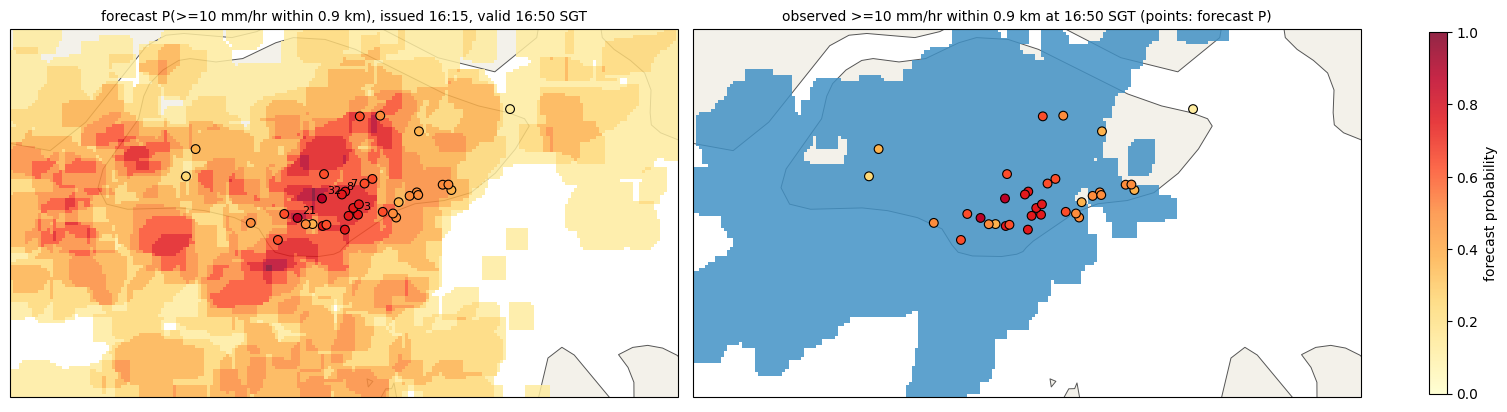

In [2]:
try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    PROJ = ccrs.PlateCarree()
except ImportError:                          # the map still renders, without a coastline
    ccrs = None

T = np.datetime64("2026-09-22T08:50", "ns")
k = int(np.where(times == T)[0][0])
issued = T - np.timedelta64((off + 1) * 5, "m")
P = neighbourhood_prob(ens[k])
O = (maximum_filter(rain.sel(time=T).values, size=2 * R + 1) >= THR).astype(float)
pub["P_16_50"] = [at(P, r) for _, r in pub.iterrows()]
pub["obs_16_50"] = [at(O, r) for _, r in pub.iterrows()]

def base(ax):
    if ccrs:
        ax.set_extent(EXTENT, crs=PROJ)
        ax.add_feature(cfeature.NaturalEarthFeature("physical", "land", "10m"),
                       facecolor="#f3f1ea", edgecolor="#555", lw=0.7, zorder=0)
    return ax

kw = {"subplot_kw": {"projection": PROJ}} if ccrs else {}
fig, axes = plt.subplots(1, 2, figsize=(15, 4.6), layout="constrained", **kw)
tr = {"transform": PROJ} if ccrs else {}
for ax, field, title, cmap in [
        (axes[0], P, f"forecast P(>=10 mm/hr within 0.9 km), issued {sgt(issued)}, valid {sgt(T)} SGT", "YlOrRd"),
        (axes[1], O, f"observed >=10 mm/hr within 0.9 km at {sgt(T)} SGT (points: forecast P)", "Blues")]:
    base(ax)
    img = ax.imshow(np.ma.masked_less(field, 0.01), extent=EXTENT, origin="upper", cmap=cmap,
                    vmin=0, vmax=1.6 if cmap == "Blues" else 1, alpha=0.85, zorder=1, **tr)
    if cmap == "YlOrRd":
        im = img
    sc = ax.scatter(pub.lon, pub.lat, c=pub.P_16_50, cmap="YlOrRd", vmin=0, vmax=1, s=40,
                    edgecolor="k", lw=0.8, zorder=3, **tr)
    ax.set_title(title, fontsize=10)
for _, r in pub.nlargest(5, "P_16_50").iterrows():
    axes[0].text(r.lon + 0.004, r.lat + 0.004, str(r.sn), fontsize=8, zorder=4, **tr)
fig.colorbar(im, ax=axes, shrink=0.8, label="forecast probability")
plt.show()

## 2. Risk-ranked PUB locations

Ranked by forecast probability at 16:50. `observed` is 1 if ≥10 mm/hr fell within 0.9 km of the point at that time.

In [3]:
cols = ["sn", "location", "P_16_50", "obs_16_50", "placement"]
pub.sort_values("P_16_50", ascending=False)[cols].head(12).round(2)

,sn,location,P_16_50,obs_16_50,placement
30,32,Junction of Stevens Road and Balmoral Road,0.88,1.0,junction: placed on the first road named
19,21,Margaret Drive / Tanglin Road,0.88,1.0,several roads listed: placed on the first
1,3,St John's Headquarters at junction of Beach Ro...,0.75,1.0,junction: placed on the first road named
33,35,Waterloo Street / Bencoolen Street / Prinsep S...,0.75,1.0,several roads listed: placed on the first
31,33,South Bridge Road / Upper Hokien Street / Uppe...,0.75,1.0,several roads listed: placed on the first
6,8,Derbyshire Road/ Cambridge Road/ Farrer Park F...,0.75,1.0,several roads listed: placed on the first
5,7,CTE (slip road to Moulmein Road),0.75,1.0,expressway slip road: placed on the road it le...
14,16,People's Association HQ at King George's Avenue,0.75,1.0,building on a road: placed on the road
8,10,Indus Road (from Havelock Road to Ganges Avenue),0.75,1.0,direct
10,12,Jalan Besar Area,0.75,1.0,area: placed at the area's geocoded point


## 3. Across the whole afternoon

A single map is one draw. Here every forecast from 15:30 to 18:30 SGT (19 issue times) is scored at every PUB point:
did the point see ≥10 mm/hr within 0.9 km at the target time, and what probability did the forecast give it? This is a
small sample from one storm (35 points × 19 times, highly correlated), so it describes this case and is not a skill
estimate. The aggregate skill scores are in `results/`.

In [4]:
recs = []
for k, t in enumerate(times):
    P = neighbourhood_prob(ens[k])
    O = maximum_filter(rain.sel(time=t).values, size=2 * R + 1) >= THR
    per = maximum_filter(rain.sel(time=t - np.timedelta64((off + 1) * 5, "m")).values, size=2 * R + 1) >= THR
    for _, r in pub.iterrows():
        recs.append(dict(sn=r.sn, target=sgt(t), P=at(P, r), obs=bool(at(O, r)), persistence=bool(at(per, r))))
sc = pd.DataFrame(recs)

def brier(p, o):
    return float(np.mean((p - o) ** 2))
bs_m, bs_p = brier(sc.P, sc.obs), brier(sc.persistence.astype(float), sc.obs)
print(f"{len(sc)} point-times, {int(sc.obs.sum())} with >= 10 mm/hr observed ({sc.obs.mean():.1%})")
print(f"Brier score: ensemble {bs_m:.3f}, persistence {bs_p:.3f}  (lower is better)")

bins = [0, 0.01, 0.25, 0.5, 1.01]
sc["P_bin"] = pd.cut(sc.P, bins, right=False, labels=["0", "0.01-0.25", "0.25-0.5", ">=0.5"])
print("\nObserved frequency of >= 10 mm/hr by forecast probability:")
print(sc.groupby("P_bin", observed=False).obs.agg(["count", "mean"]).rename(columns={"mean": "observed freq"}).round(2))

site = (sc.groupby("sn").agg(max_P=("P", "max"), times_forecast_025=("P", lambda p: int((p >= 0.25).sum())),
                             times_observed=("obs", "sum"))
          .join(pub.set_index("sn")[["location"]]).sort_values("max_P", ascending=False))
site.head(10).round(2)            # counts are out of 19 target times

665 point-times, 339 with >= 10 mm/hr observed (51.0%)
Brier score: ensemble 0.225, persistence 0.341  (lower is better)

Observed frequency of >= 10 mm/hr by forecast probability:
           count  observed freq
P_bin                          
0            292           0.10
0.01-0.25     86           0.49
0.25-0.5     152           0.88
>=0.5        135           0.99


,max_P,times_forecast_025,times_observed,location
sn,,,,
1,1.00,7,11,Prince Philip Avenue / Jervois Road
14,1.00,7,10,Jalan Mat Jambol
20,1.00,8,11,State Land at junction of Alexandra Road and L...
21,1.00,7,11,Margaret Drive / Tanglin Road
32,0.88,8,11,Junction of Stevens Road and Balmoral Road
33,0.88,8,9,South Bridge Road / Upper Hokien Street / Uppe...
11,0.88,9,10,Jalan Benaan Kapal
29,0.88,6,8,Second Chin Bee Road
26,0.88,7,12,Junction of Neo Pee Teck Lane and Pasir Panjan...


**Reading the afternoon scores.** This storm covered most of central Singapore, so about half of all
point-times were wet. The ensemble beats persistence on the Brier score, mainly because it lets the storm decay while
persistence keeps it. The table of observed frequency by forecast probability shows the ensemble is **under-confident**
on this case: points given 0.25–0.5 were wet ~88% of the time, and even points given 0.01–0.25 were wet about half the
time. This is the intensity bias seen in the aggregate evaluation (members too weak, so fewer of them cross 10 mm/hr).
In practice a low but non-zero probability near a flood-prone point should be read as a real warning, not as
background noise.

## 4. Other leads

The probability each lead's model gave the PUB points for 16:50 SGT. Longer leads are issued earlier (16:15, 15:45,
15:15 SGT). The 60- and 90-min models (warm-started from the 30-min model) give no point more than 0.12, although 33 of 35 points
were wet. On the test period they match persistence for light rain but lose it for heavy rain (notebook 02, section 6),
so **only the 30-min map should be used for flood-risk warnings**.

In [5]:
for lead in (30, 60, 90):
    p = ROOT / f"data/processed/eval_cache/case_22sep_lead{lead}.npz"
    if not p.exists():
        print(f"lead {lead}: no cache yet"); continue
    zz = np.load(p)
    tt = zz["target_times"].astype("datetime64[ns]")
    kk = int(np.where(tt == T)[0][0])
    PP = neighbourhood_prob(zz["ens"].astype("float32")[kk])
    vals = np.array([at(PP, r) for _, r in pub.iterrows()])
    issued_l = T - np.timedelta64((int(zz["lead_steps"]) + 1) * 5, "m")
    print(f"lead {lead}: issued {sgt(issued_l)}, PUB points with P >= 0.25: {(vals >= 0.25).sum()}, "
          f"max P {vals.max():.2f}; observed wet points: {int(pub.obs_16_50.sum())}")

lead 30: issued 16:15, PUB points with P >= 0.25: 34, max P 0.88; observed wet points: 33
lead 60: issued 15:45, PUB points with P >= 0.25: 13, max P 0.50; observed wet points: 33
lead 90: issued 15:15, PUB points with P >= 0.25: 0, max P 0.12; observed wet points: 33


## 5. Limitations

- **Points, not areas.** PUB names roads and estates; each is geocoded to one point, and junctions are placed on the first
  road named. A 0.9 km neighbourhood is used partly to absorb this.
- **The PUB list is about drainage, not today's weather.** It marks places that have flooded before. On 22 Sep the flash
  floods were on King's Road and Coronation Road, which are **not** on the list; the nearest listed location
  (Stevens Road / Balmoral Road) is about 2.5 km away. A rain-probability map is useful on its own, not only at listed
  points.
- **Rain is not flooding.** Whether ≥10 mm/hr floods a road depends on drainage capacity, antecedent rain and tide; the
  map shows the meteorological hazard only.
- **Known model bias.** The ensemble under-predicts intensity (bias ≈0.5 at ≥10 mm/hr) and misses rapid initiation,
  so its probabilities are too low (section 3). Do not threshold them at 0.5. See notebook 02 and
  `tasks/replan_stage4_5.md`.
- **One event.** Everything here is from a single storm; aggregate skill is in `results/`.